<a href="https://colab.research.google.com/github/amanpoonia/Research_project_Prof.Nour/blob/main/walkforward%2Bcosts.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# STEP 1 — Setup, configuration, data
# ============================================================
!pip install -q yfinance

import numpy as np
import pandas as pd
import yfinance as yf

# ---------------- Configuration (used by all later steps) ----------------
TICKER       = "EURUSD=X"
START_DATE   = "2003-12-01"    # sample of the transition-table document
END_DATE     = "2025-12-31"    # inclusive

STATES       = (-1, 0, 1)
QUANTILES    = (0.30, 0.70)    # bucket cutoffs: -1 | 0 | +1
MAX_DEPTH    = 5               # M1 ... M5
MIN_NODE_OBS = 30              # min observations in every child for a split
ALPHA        = 0.10            # significance level of the split test
N_PERM       = 999             # permutations per split test
SEED         = 42

OUTLIER_FLAG = 4.0             # |return| in % above this is printed for inspection


def load_returns(ticker=TICKER, start=START_DATE, end=END_DATE):
    """Download daily closes and return close-to-close log returns in percent."""
    end_excl = pd.Timestamp(end) + pd.Timedelta(days=1)      # yfinance end is exclusive
    px = yf.download(ticker, start=start, end=end_excl,
                     auto_adjust=False, progress=False)["Close"]
    px = px.squeeze()                                        # 1-column DataFrame -> Series
    px = px[~px.index.duplicated(keep="last")].dropna()
    px = px[px > 0].sort_index()

    ret = 100.0 * np.log(px).diff().dropna()
    ret.name = "ret"

    print(f"{len(ret)} returns | {ret.index[0].date()} -> {ret.index[-1].date()} "
          f"| {int((ret == 0.0).sum())} zero returns (kept)")

    big = ret[ret.abs() > OUTLIER_FLAG]
    if len(big):
        print(f"{len(big)} returns with |r| > {OUTLIER_FLAG}% (check these):")
        print(big.round(3).to_string())
    return ret


ret = load_returns()

5729 returns | 2003-12-02 -> 2025-12-31 | 25 zero returns (kept)
10 returns with |r| > 4.0% (check these):
Date
2008-01-08     5.872
2008-01-09    -6.001
2008-02-08     7.272
2008-02-11    -7.112
2008-09-08     5.288
2008-09-09    -6.177
2008-10-08     9.599
2008-10-09    -9.526
2008-12-08    15.963
2008-12-09   -14.332


In [2]:
# ============================================================
# STEP 2 — Discretisation: returns -> states (-1, 0, +1)
# ============================================================

def fit_cutoffs(train_ret, quantiles=QUANTILES):
    """Lower and upper bucket cutoffs, estimated on the given returns only."""
    lo, hi = np.quantile(train_ret.to_numpy(), quantiles)
    return float(lo), float(hi)


def to_states(ret, cutoffs):
    """Map returns to states: -1 below the lower cutoff, +1 above the upper, 0 between."""
    lo, hi = cutoffs
    r = ret.to_numpy()
    s = np.zeros(len(r), dtype=np.int8)
    s[r < lo] = -1
    s[r > hi] = 1
    return pd.Series(s, index=ret.index, name="state")


# Full-sample version, only to reproduce the transition-table document
cutoffs = fit_cutoffs(ret)
states  = to_states(ret, cutoffs)

print(f"cutoffs: {cutoffs[0]:.4f}% / {cutoffs[1]:.4f}%")
print((100 * states.value_counts(normalize=True).sort_index()).round(2).to_string())

cutoffs: -0.2338% / 0.2466%
state
-1    30.01
 0    39.99
 1    30.01


In [3]:
# ============================================================
# STEP 3 — Contexts and transition tables M1 ... M5
# ============================================================
from itertools import product


def context_codes(states, depth):
    """Integer code of the `depth` states before each day, plus that day's position.
    Context order: oldest ... yesterday (oldest is the fastest-changing digit)."""
    s = states.to_numpy().astype(np.int64) + 1                      # 0, 1, 2
    win = np.lib.stride_tricks.sliding_window_view(s, depth)[:-1]   # row = oldest ... yesterday
    codes = win @ (3 ** np.arange(depth))
    return codes, np.arange(depth, len(s))


def transition_table(ret, states, depth):
    """Transition table for contexts of length `depth` (tuple = oldest ... yesterday)."""
    codes, pos = context_codes(states, depth)
    nxt = states.to_numpy()[pos].astype(np.int64) + 1               # tomorrow's state
    r   = ret.to_numpy()[pos]                                       # tomorrow's return

    n   = np.zeros((3 ** depth, 3))                                 # counts
    tot = np.zeros((3 ** depth, 3))                                 # summed returns
    np.add.at(n,   (codes, nxt), 1.0)
    np.add.at(tot, (codes, nxt), r)

    n_ctx = n.sum(axis=1)
    with np.errstate(invalid="ignore", divide="ignore"):
        prob  = n / n_ctx[:, None]
        mean  = tot / n
        final = tot.sum(axis=1) / n_ctx

    labels = [c[::-1] for c in product(STATES, repeat=depth)]       # same row order as the document
    out = pd.DataFrame(index=pd.Index(labels, tupleize_cols=False, name=f"M{depth}"))
    out["N"]          = n_ctx.astype(int)
    out["State_Prob"] = 100 * n_ctx / n_ctx.sum()
    for j, st in enumerate(STATES):
        out[f"Prob_{st}"] = 100 * prob[:, j]
    for j, st in enumerate(STATES):
        out[f"Ret_{st}"] = mean[:, j]
    out["Final_Ret"]  = final
    return out


ROUND = {"State_Prob": 2, "Prob_-1": 2, "Prob_0": 2, "Prob_1": 2,
         "Ret_-1": 3, "Ret_0": 3, "Ret_1": 3, "Final_Ret": 3}

tables = {d: transition_table(ret, states, d) for d in range(1, MAX_DEPTH + 1)}

print(tables[1].round(ROUND).to_string(), "\n")
print(tables[2].round(ROUND).to_string())

          N  State_Prob  Prob_-1  Prob_0  Prob_1  Ret_-1  Ret_0  Ret_1  Final_Ret
M1                                                                               
(-1,)  1719       30.01    28.50   38.57   32.93  -0.674  0.007  0.687      0.037
(0,)   2290       39.98    29.00   41.35   29.65  -0.591 -0.001  0.600      0.006
(1,)   1719       30.01    32.87   39.62   27.52  -0.705  0.004  0.666     -0.047 

            N  State_Prob  Prob_-1  Prob_0  Prob_1  Ret_-1  Ret_0  Ret_1  Final_Ret
M2                                                                                 
(-1, -1)  490        8.56    26.33   37.55   36.12  -0.688  0.011  0.654      0.059
(0, -1)   664       11.59    28.61   43.07   28.31  -0.614  0.006  0.681      0.020
(1, -1)   565        9.87    30.27   34.16   35.58  -0.730  0.005  0.721      0.037
(-1, 0)   663       11.58    31.37   39.82   28.81  -0.616 -0.001  0.595     -0.022
(0, 0)    946       16.52    27.38   42.71   29.92  -0.581 -0.000  0.576      0.013


                 tomorrow = -1  tomorrow = 0  tomorrow = +1
day before = -1            129           184            177
day before = 0             190           286            188
day before = +1            171           193            201

chi2 = 14.92 | p = 0.005 | SPLIT at alpha = 0.1


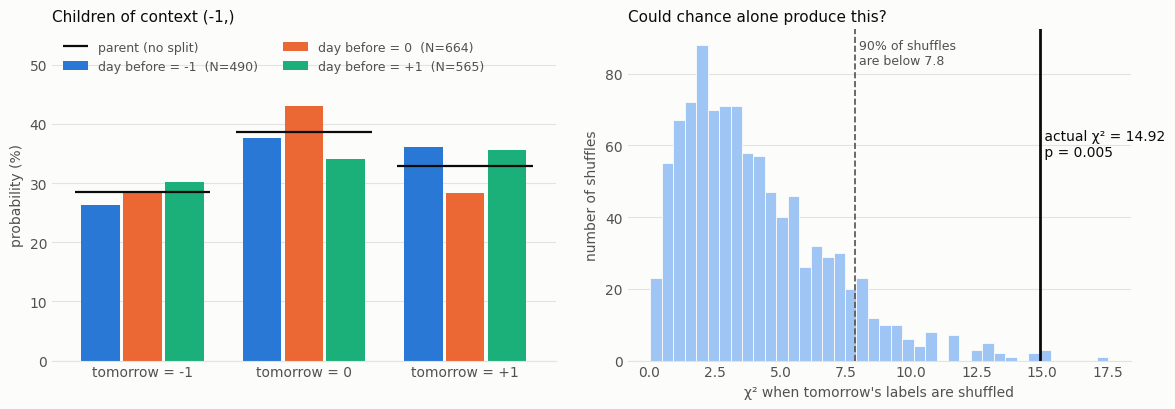

In [4]:
# ============================================================
# STEP 4 — Split test: does one more lag add information?
# ============================================================
import matplotlib.pyplot as plt


def lab(state):
    """Display label of a state: -1, 0, +1."""
    return f"{state:+d}" if state else "0"


def context_code(context):
    """Integer code of a context tuple (oldest ... yesterday), as in context_codes."""
    return sum((s + 1) * 3 ** k for k, s in enumerate(context))


def node_split_data(states, context):
    """For every day whose history ends with `context`, return the state one day
    further back (the candidate lag), tomorrow's state, and the day's position."""
    depth = len(context)
    codes, pos = context_codes(states, depth + 1)
    in_node = (codes // 3) == context_code(context)      # drop the oldest digit -> parent context
    return codes[in_node] % 3 - 1, states.to_numpy()[pos[in_node]], pos[in_node]


def chi2_stat(tables, expected):
    """Pearson chi-squared of one table (3x3) or a stack of tables (n x 3 x 3)."""
    ok = expected > 0
    dev = np.where(ok, (tables - expected) ** 2 / np.where(ok, expected, 1.0), 0.0)
    return dev.sum(axis=(-2, -1))


def split_test(lag_state, nxt_state, n_perm=N_PERM, rng=None):
    """Permutation test of H0: given the context, tomorrow's state does not depend
    on the candidate lag. Statistic: Pearson chi-squared of the 3x3 table."""
    rng = np.random.default_rng(SEED) if rng is None else rng
    a = np.asarray(lag_state, dtype=np.int64) + 1        # rows: candidate lag
    b = np.asarray(nxt_state, dtype=np.int64) + 1        # cols: tomorrow
    n = len(a)

    table    = np.bincount(a * 3 + b, minlength=9).reshape(3, 3)
    expected = np.outer(table.sum(axis=1), table.sum(axis=0)) / n
    chi2     = float(chi2_stat(table, expected))

    # shuffle tomorrow's labels inside the node, keep the candidate lag fixed
    shuffled = rng.permuted(np.tile(b, (n_perm, 1)), axis=1)
    cells    = np.arange(n_perm)[:, None] * 9 + a[None, :] * 3 + shuffled
    null_tab = np.bincount(cells.ravel(), minlength=9 * n_perm).reshape(n_perm, 3, 3)
    null     = chi2_stat(null_tab, expected)

    p_value = (1 + np.sum(null >= chi2 - 1e-12)) / (n_perm + 1)
    return {"table": table, "expected": expected, "chi2": chi2,
            "p_value": float(p_value), "null": null}


def plot_split_test(res, context, alpha=ALPHA):
    """Left: tomorrow's distribution in each child vs the parent. Right: shuffled chi2 vs actual."""
    INK, MUTED, GRID = "#0b0b0b", "#52514e", "#e4e3df"
    COL = ["#2a78d6", "#eb6834", "#1baf7a"]
    table = res["table"]
    child = 100 * table / table.sum(axis=1, keepdims=True)
    parent = 100 * table.sum(axis=0) / table.sum()

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2), facecolor="#fcfcfb")
    for ax in (ax1, ax2):
        ax.set_facecolor("#fcfcfb")
        ax.spines[["top", "right", "left"]].set_visible(False)
        ax.spines["bottom"].set_color(GRID)
        ax.tick_params(colors=MUTED, length=0)
        ax.grid(axis="y", color=GRID, linewidth=0.8)
        ax.set_axisbelow(True)

    w = 0.24
    for i, st in enumerate(STATES):                       # one colour per child
        ax1.bar(np.arange(3) + (i - 1) * (w + 0.02), child[i], w, color=COL[i],
                label=f"day before = {lab(st)}  (N={table[i].sum()})")
    for j in range(3):                                    # parent = what H0 expects
        ax1.hlines(parent[j], j - 0.42, j + 0.42, color=INK, linewidth=1.6,
                   label="parent (no split)" if j == 0 else None)
    ax1.set_xticks(range(3), [f"tomorrow = {lab(st)}" for st in STATES])
    ax1.set_ylabel("probability (%)", color=MUTED)
    ax1.set_title(f"Children of context {context}", loc="left", color=INK, fontsize=11)
    ax1.set_ylim(0, 1.3 * child.max())
    ax1.legend(frameon=False, fontsize=9, labelcolor=MUTED, loc="upper left", ncol=2)

    cut = np.quantile(res["null"], 1 - alpha)
    ax2.hist(res["null"], bins=40, color="#9ec5f4", edgecolor="#fcfcfb", linewidth=0.6)
    ax2.axvline(cut, color=MUTED, linewidth=1.2, linestyle="--")
    ax2.axvline(res["chi2"], color=INK, linewidth=2)
    top = ax2.get_ylim()[1]
    ax2.text(cut, top * 0.97, f" {1 - alpha:.0%} of shuffles\n are below {cut:.1f}",
             color=MUTED, fontsize=9, va="top")
    ax2.text(res["chi2"], top * 0.70, f" actual χ² = {res['chi2']:.2f}\n p = {res['p_value']:.3f}",
             color=INK, fontsize=10, va="top")
    ax2.set_xlabel("χ² when tomorrow's labels are shuffled", color=MUTED)
    ax2.set_ylabel("number of shuffles", color=MUTED)
    ax2.set_title("Could chance alone produce this?", loc="left", color=INK, fontsize=11)
    plt.tight_layout()
    plt.show()


# Example: parent context "yesterday = -1"; does the day before add information?
context = (-1,)
lag_state, nxt_state, _ = node_split_data(states, context)
res = split_test(lag_state, nxt_state)

print(pd.DataFrame(res["table"], index=[f"day before = {lab(s)}" for s in STATES],
                   columns=[f"tomorrow = {lab(s)}" for s in STATES]))
print(f"\nchi2 = {res['chi2']:.2f} | p = {res['p_value']:.3f} | "
      f"{'SPLIT' if res['p_value'] < ALPHA else 'no split'} at alpha = {ALPHA}")
plot_split_test(res, context)

7 nodes | 5 leaves | max depth 2
status
leaf: not significant    5
split                    2 

    context  depth     N  Prob_-1  Prob_0  Prob_1  pred  Final_Ret   chi2  p_value                 status
0        ()      0  5728    30.01   40.00   29.99     0     -0.001  17.29    0.002                  split
1     (-1,)      1  1719    28.50   38.57   32.93     0      0.037  14.92    0.006                  split
2      (0,)      1  2290    29.00   41.35   29.65     0      0.006   3.19    0.542  leaf: not significant
3      (1,)      1  1718    32.89   39.64   27.47     0     -0.047   5.71    0.232  leaf: not significant
4  (-1, -1)      2   490    26.33   37.55   36.12     0      0.059   2.16    0.666  leaf: not significant
5   (0, -1)      2   664    28.61   43.07   28.31     0      0.020   6.86    0.145  leaf: not significant
6   (1, -1)      2   565    30.27   34.16   35.58     1      0.037   1.28    0.861  leaf: not significant


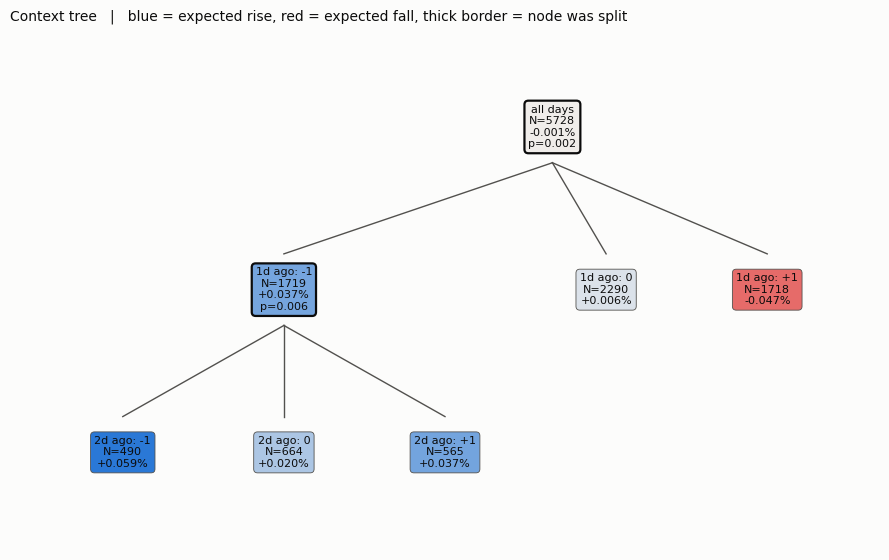

In [5]:
# ============================================================
# STEP 5 — Grow the context tree
# ============================================================
from matplotlib.colors import LinearSegmentedColormap


def make_node(context, nxt_state, nxt_ret):
    """Node of the tree: what tomorrow looked like after this context."""
    counts = np.bincount(np.asarray(nxt_state, dtype=np.int64) + 1, minlength=3)
    return {"context": context, "depth": len(context), "N": int(counts.sum()),
            "prob": counts / counts.sum(),                 # P(tomorrow = -1, 0, +1)
            "pred": STATES[int(np.argmax(counts))],        # predicted bucket
            "exp_ret": float(np.mean(nxt_ret)),            # expected return, % per day
            "chi2": np.nan, "p_value": np.nan, "status": "", "children": []}


def grow_tree(ret, states, max_depth=MAX_DEPTH, min_obs=MIN_NODE_OBS,
              alpha=ALPHA, n_perm=N_PERM, seed=SEED):
    """Grow the context tree. Returns {context tuple: node}; () is the root."""
    rng, r, tree = np.random.default_rng(seed), ret.to_numpy(), {}

    def build(context):
        lag, nxt, pos = node_split_data(states, context)
        node = tree[context] = make_node(context, nxt, r[pos])

        if node["depth"] == max_depth:
            node["status"] = "leaf: max depth"
            return
        big = [c for c in STATES if np.sum(lag == c) >= min_obs]   # children large enough
        if len(big) < 2:
            node["status"] = "leaf: too few observations"
            return
        res = split_test(lag, nxt, n_perm=n_perm, rng=rng)
        node["chi2"], node["p_value"] = res["chi2"], res["p_value"]
        if res["p_value"] >= alpha:
            node["status"] = "leaf: not significant"
            return
        node["status"] = "split"
        for c in big:
            node["children"].append((c,) + context)                # one more day back, on the left
            build((c,) + context)

    build(())
    return tree


def tree_table(tree):
    """One row per node, shallow to deep."""
    rows = [{"context": n["context"], "depth": n["depth"], "N": n["N"],
             "Prob_-1": 100 * n["prob"][0], "Prob_0": 100 * n["prob"][1],
             "Prob_1": 100 * n["prob"][2], "pred": n["pred"], "Final_Ret": n["exp_ret"],
             "chi2": n["chi2"], "p_value": n["p_value"], "status": n["status"]}
            for n in tree.values()]
    return pd.DataFrame(rows).sort_values(["depth", "context"]).reset_index(drop=True)


def plot_tree(tree, title="Context tree"):
    """Draw the tree. Each box: state added, N, expected return. Colour = expected return."""
    INK, MUTED, SURF = "#0b0b0b", "#52514e", "#fcfcfb"
    cmap = LinearSegmentedColormap.from_list("div", ["#e34948", "#f0efec", "#2a78d6"])
    x, next_x = {}, [0.0]

    def place(ctx):                                       # leaves left to right, parents centred
        kids = tree[ctx]["children"]
        for k in kids:
            place(k)
        if kids:
            x[ctx] = np.mean([x[k] for k in kids])
        else:
            x[ctx] = next_x[0]
            next_x[0] += 1.0

    place(())
    depth = max(n["depth"] for n in tree.values())
    scale = max(abs(n["exp_ret"]) for n in tree.values())

    fig, ax = plt.subplots(figsize=(max(9, 1.05 * next_x[0]), 1.9 * (depth + 1)), facecolor=SURF)
    ax.set_facecolor(SURF)
    ax.axis("off")
    for ctx, n in tree.items():
        for k in n["children"]:
            ax.plot([x[ctx], x[k]], [-n["depth"] - 0.22, -n["depth"] - 0.78], color=MUTED, lw=1)
        name = "all days" if not ctx else f"{n['depth']}d ago: {lab(ctx[0])}"
        text = f"{name}\nN={n['N']}\n{n['exp_ret']:+.3f}%"
        if n["status"] == "split":
            text += f"\np={n['p_value']:.3f}"
        ax.text(x[ctx], -n["depth"], text, ha="center", va="center", fontsize=8, color=INK,
                bbox=dict(boxstyle="round,pad=0.35", lw=1.6 if n["status"] == "split" else 0.6,
                          ec=INK if n["status"] == "split" else MUTED,
                          fc=cmap(0.5 + 0.5 * n["exp_ret"] / scale)))
    ax.set_xlim(-0.7, next_x[0] - 0.3)
    ax.set_ylim(-depth - 0.6, 0.6)
    ax.set_title(f"{title}   |   blue = expected rise, red = expected fall, "
                 f"thick border = node was split", loc="left", fontsize=10, color=INK)
    plt.tight_layout()
    plt.show()


tree = grow_tree(ret, states)
summary = tree_table(tree)

print(f"{len(tree)} nodes | {int((summary.status != 'split').sum())} leaves | "
      f"max depth {summary.depth.max()}")
print(summary.status.value_counts().to_string(), "\n")
print(summary.round({"Prob_-1": 2, "Prob_0": 2, "Prob_1": 2, "Final_Ret": 3,
                     "chi2": 2, "p_value": 3}).to_string())
plot_tree(tree)

           context  depth  pred  exp_ret  Prob_-1  Prob_0  Prob_1
Date                                                             
2025-12-24    (1,)      1     0   -0.047   32.887  39.639  27.474
2025-12-26    (0,)      1     0    0.006   28.996  41.354  29.651
2025-12-29    (0,)      1     0    0.006   28.996  41.354  29.651
2025-12-30    (0,)      1     0    0.006   28.996  41.354  29.651
2025-12-31    (0,)      1     0    0.006   28.996  41.354  29.651 

actual       -1     0     1
predicted                  
-1            0     0     0
 0         1548  2098  1517
 1          171   193   201


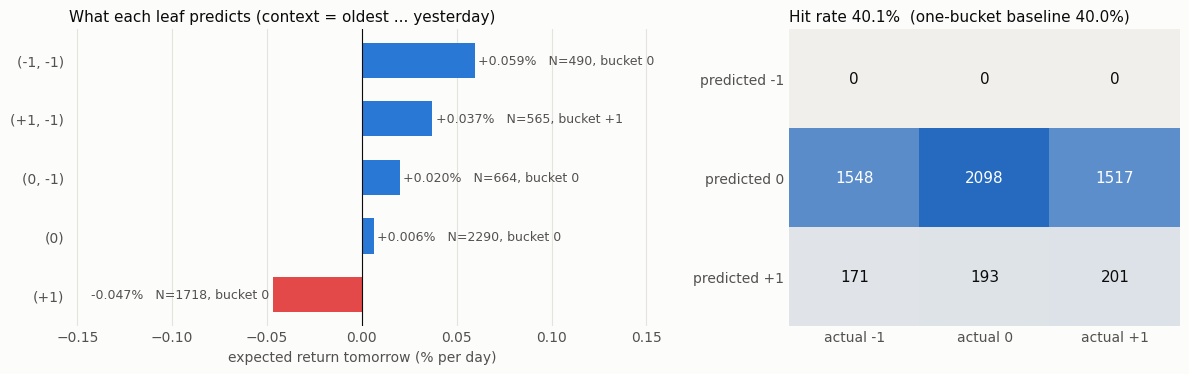

In [6]:
# ============================================================
# STEP 6 — Prediction: walk the tree to the matching leaf
# ============================================================

def find_node(tree, history):
    """Deepest node whose context matches the end of `history` (oldest ... latest)."""
    context = ()
    while len(context) < len(history):
        longer = (int(history[-len(context) - 1]),) + context     # add one more day back
        if longer not in tree:
            break
        context = longer
    return tree[context]


def predict(tree, states):
    """Row t = prediction for day t+1, made at the close of day t from states up to t."""
    s = states.to_numpy()
    depth = max(n["depth"] for n in tree.values())
    rows = []
    for t in range(len(s)):
        n = find_node(tree, s[max(0, t - depth + 1): t + 1])
        rows.append((n["context"], n["depth"], n["pred"], n["exp_ret"], *(100 * n["prob"])))
    return pd.DataFrame(rows, index=states.index,
                        columns=["context", "depth", "pred", "exp_ret",
                                 "Prob_-1", "Prob_0", "Prob_1"])


def confusion(pred, states):
    """Counts of predicted bucket (rows) against the bucket that actually followed (columns)."""
    actual = states.shift(-1).iloc[:-1].astype(int)               # tomorrow's state
    return (pd.crosstab(pred["pred"].iloc[:-1], actual)
              .reindex(index=STATES, columns=STATES, fill_value=0)
              .rename_axis(index="predicted", columns="actual"))


def plot_predictions(tree, conf):
    """Left: expected return of each leaf. Right: predicted vs actual bucket."""
    INK, MUTED, GRID, SURF = "#0b0b0b", "#52514e", "#e4e3df", "#fcfcfb"
    leaves = sorted((n for n in tree.values() if n["status"] != "split"),
                    key=lambda n: n["exp_ret"])
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, max(3.8, 0.45 * len(leaves) + 1.6)),
                                   facecolor=SURF, gridspec_kw={"width_ratios": [1.5, 1]})
    for ax in (ax1, ax2):
        ax.set_facecolor(SURF)
        ax.spines[:].set_visible(False)
        ax.tick_params(colors=MUTED, length=0)

    y = np.arange(len(leaves))
    val = np.array([n["exp_ret"] for n in leaves])
    ax1.barh(y, val, height=0.6, color=np.where(val >= 0, "#2a78d6", "#e34948"))
    ax1.axvline(0, color=INK, lw=0.8)
    pad = 0.03 * np.abs(val).max()
    for i, n in enumerate(leaves):
        ax1.text(val[i] + (pad if val[i] >= 0 else -pad), i,
                 f"{val[i]:+.3f}%   N={n['N']}, bucket {lab(n['pred'])}",
                 va="center", ha="left" if val[i] >= 0 else "right", fontsize=9, color=MUTED)
    ax1.set_yticks(y, ["(" + ", ".join(lab(c) for c in n["context"]) + ")" for n in leaves])
    ax1.set_xlim(-2.6 * np.abs(val).max(), 2.6 * np.abs(val).max())
    ax1.grid(axis="x", color=GRID, lw=0.8)
    ax1.set_axisbelow(True)
    ax1.set_xlabel("expected return tomorrow (% per day)", color=MUTED)
    ax1.set_title("What each leaf predicts (context = oldest ... yesterday)",
                  loc="left", fontsize=11, color=INK)

    c = conf.to_numpy()
    ax2.imshow(c, cmap=LinearSegmentedColormap.from_list("seq", ["#f0efec", "#256abf"]),
               vmin=0, aspect="auto")
    for i in range(3):
        for j in range(3):
            ax2.text(j, i, f"{c[i, j]}", ha="center", va="center", fontsize=11,
                     color="#ffffff" if c[i, j] > 0.6 * c.max() else INK)
    ax2.set_xticks(range(3), [f"actual {lab(s)}" for s in STATES])
    ax2.set_yticks(range(3), [f"predicted {lab(s)}" for s in STATES])
    hit, base = np.trace(c) / c.sum(), c.sum(axis=0).max() / c.sum()
    ax2.set_title(f"Hit rate {hit:.1%}  (one-bucket baseline {base:.1%})",
                  loc="left", fontsize=11, color=INK)
    plt.tight_layout()
    plt.show()


pred = predict(tree, states)
conf = confusion(pred, states)

print(pred.tail(5).round(3).to_string(), "\n")
print(conf.to_string())
plot_predictions(tree, conf)

     train_start   train_end  test_start    test_end  n_train  n_test  cut_lo  cut_hi  nodes  max_depth                                    leaves
fold                                                                                                                                             
0     2003-12-02  2013-11-29  2013-12-02  2014-12-01     2583     261 -0.2607  0.3000      4          1                       [(-1,), (0,), (1,)]
1     2003-12-02  2014-12-01  2014-12-02  2015-12-01     2844     261 -0.2475  0.2782      4          1                       [(-1,), (0,), (1,)]
2     2003-12-02  2015-12-01  2015-12-02  2016-12-01     3105     262 -0.2651  0.2781      4          1                       [(-1,), (0,), (1,)]
3     2003-12-02  2016-12-01  2016-12-02  2017-12-01     3367     259 -0.2604  0.2703      4          1                       [(-1,), (0,), (1,)]
4     2003-12-02  2017-12-01  2017-12-04  2018-11-30     3626     260 -0.2566  0.2722      4          1                     

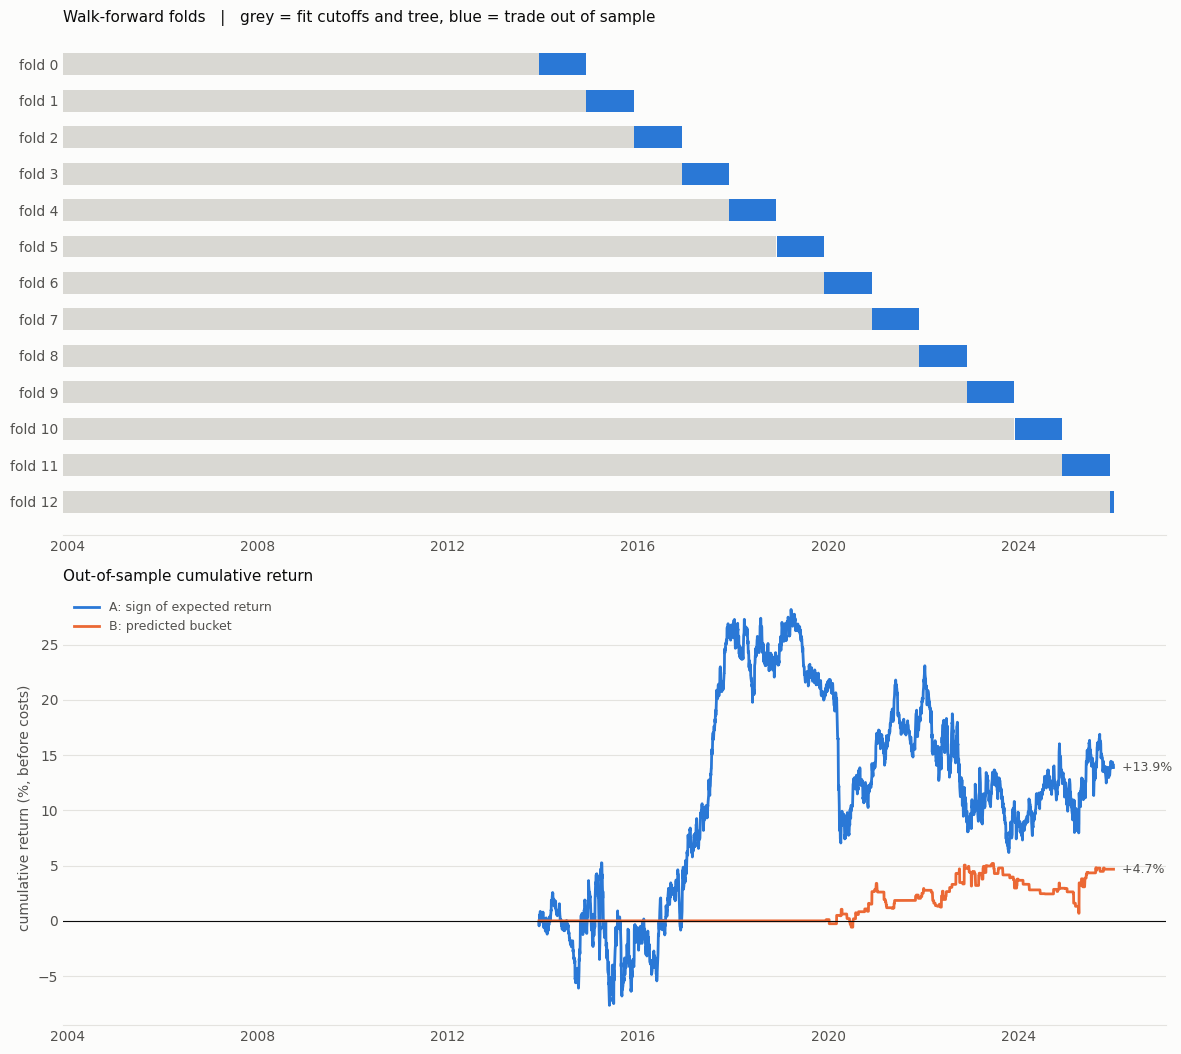

In [7]:
# ============================================================
# STEP 7 — Walk-forward backtest (gross of costs)
# ============================================================
TRAIN_YEARS = 10       # length of the first training window
TEST_MONTHS = 12       # refit the cutoffs and the tree this often
EXPANDING   = True     # True: train on all past data; False: rolling TRAIN_YEARS window


def make_folds(index, train_years=TRAIN_YEARS, test_months=TEST_MONTHS, expanding=EXPANDING):
    """List of (train_start, test_start, test_end) dates; test = [test_start, test_end)."""
    folds, test_start = [], index[0] + pd.DateOffset(years=train_years)
    while test_start <= index[-1]:
        test_end = test_start + pd.DateOffset(months=test_months)
        train_start = index[0] if expanding else test_start - pd.DateOffset(years=train_years)
        folds.append((train_start, test_start, test_end))
        test_start = test_end
    return folds


def walk_forward(ret, folds=None):
    """Refit cutoffs and tree on each training window, trade the following test window.
    Returns (bt, info): bt = one row per out-of-sample day, info = one row per fold."""
    folds = make_folds(ret.index) if folds is None else folds
    parts, info = [], []
    for k, (train_start, test_start, test_end) in enumerate(folds):
        train = ret[(ret.index >= train_start) & (ret.index < test_start)]
        upto  = ret[(ret.index >= train_start) & (ret.index < test_end)]

        cutoffs = fit_cutoffs(train)                              # training data only
        tree    = grow_tree(train, to_states(train, cutoffs))     # training data only

        # signal for day d is the prediction made at the close of day d-1
        signal = predict(tree, to_states(upto, cutoffs)).shift(1)
        test   = signal[signal.index >= test_start].copy()
        test["ret"]  = upto[test.index]
        test["fold"] = k
        parts.append(test)

        info.append({"fold": k, "train_start": train.index[0].date(),
                     "train_end": train.index[-1].date(), "test_start": test.index[0].date(),
                     "test_end": test.index[-1].date(), "n_train": len(train),
                     "n_test": len(test), "cut_lo": cutoffs[0], "cut_hi": cutoffs[1],
                     "nodes": len(tree), "max_depth": max(n["depth"] for n in tree.values()),
                     "leaves": sorted(n["context"] for n in tree.values()
                                      if n["status"] != "split")})

    bt = pd.concat(parts)
    in_tree = bt["depth"] > 0                                     # root only = no memory = no trade
    bt["pos_ret"]      = np.where(in_tree, np.sign(bt["exp_ret"]), 0.0)    # rule A: sign of expected return
    bt["pos_bucket"]   = np.where(in_tree, bt["pred"], 0.0)                # rule B: predicted bucket
    bt["strat_ret"]    = bt["pos_ret"] * bt["ret"]                # % per day, before costs
    bt["strat_bucket"] = bt["pos_bucket"] * bt["ret"]
    return bt, pd.DataFrame(info).set_index("fold")


def plot_folds(info, ax):
    """Timeline of the folds: grey = training window, blue = test window."""
    for k, f in info.iterrows():
        ax.barh(k, (pd.Timestamp(f.train_end) - pd.Timestamp(f.train_start)).days,
                left=pd.Timestamp(f.train_start), height=0.6, color="#d9d8d3")
        ax.barh(k, (pd.Timestamp(f.test_end) - pd.Timestamp(f.test_start)).days,
                left=pd.Timestamp(f.test_start), height=0.6, color="#2a78d6")
    ax.invert_yaxis()
    ax.set_yticks(info.index, [f"fold {k}" for k in info.index])
    ax.set_title("Walk-forward folds   |   grey = fit cutoffs and tree, blue = trade out of sample",
                 loc="left", fontsize=11, color="#0b0b0b")


def plot_walk_forward(bt, info):
    """Top: fold timeline. Bottom: cumulative out-of-sample return of both rules."""
    INK, MUTED, GRID, SURF = "#0b0b0b", "#52514e", "#e4e3df", "#fcfcfb"
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 3 + 0.28 * len(info) + 4), facecolor=SURF,
                                   gridspec_kw={"height_ratios": [0.28 * len(info) + 1, 4]})
    for ax in (ax1, ax2):
        ax.set_facecolor(SURF)
        ax.spines[["top", "right", "left"]].set_visible(False)
        ax.spines["bottom"].set_color(GRID)
        ax.tick_params(colors=MUTED, length=0)
    plot_folds(info, ax1)

    for col, name, colour in (("strat_ret", "A: sign of expected return", "#2a78d6"),
                              ("strat_bucket", "B: predicted bucket", "#eb6834")):
        curve = bt[col].cumsum()
        ax2.plot(curve.index, curve, color=colour, lw=2, label=name)
        ax2.text(curve.index[-1], curve.iloc[-1], f"  {curve.iloc[-1]:+.1f}%",
                 color=MUTED, fontsize=9, va="center")
    ax2.axhline(0, color=INK, lw=0.8)
    ax2.grid(axis="y", color=GRID, lw=0.8)
    ax2.set_xlim(ax1.get_xlim())
    ax2.set_ylabel("cumulative return (%, before costs)", color=MUTED)
    ax2.set_title("Out-of-sample cumulative return", loc="left", fontsize=11, color=INK)
    ax2.legend(frameon=False, fontsize=9, labelcolor=MUTED, loc="upper left")
    plt.tight_layout()
    plt.show()


bt, info = walk_forward(ret)

pd.set_option("display.width", 250)
print(info.round(4).to_string(), "\n")
print(f"{len(bt)} out-of-sample days | in the market: "
      f"A {100 * (bt.pos_ret != 0).mean():.0f}% of days, B {100 * (bt.pos_bucket != 0).mean():.0f}%")
plot_walk_forward(bt, info)

In [8]:
print(info[["test_start", "test_end", "nodes", "max_depth", "leaves"]].to_string())
print(bt[["strat_ret", "strat_bucket"]].sum().round(2))

      test_start    test_end  nodes  max_depth                                    leaves
fold                                                                                    
0     2013-12-02  2014-12-01      4          1                       [(-1,), (0,), (1,)]
1     2014-12-02  2015-12-01      4          1                       [(-1,), (0,), (1,)]
2     2015-12-02  2016-12-01      4          1                       [(-1,), (0,), (1,)]
3     2016-12-02  2017-12-01      4          1                       [(-1,), (0,), (1,)]
4     2017-12-04  2018-11-30      4          1                       [(-1,), (0,), (1,)]
5     2018-12-03  2019-11-29      4          1                       [(-1,), (0,), (1,)]
6     2019-12-02  2020-12-01      7          2  [(-1, -1), (0,), (0, -1), (1,), (1, -1)]
7     2020-12-02  2021-12-01      7          2  [(-1, -1), (0,), (0, -1), (1,), (1, -1)]
8     2021-12-02  2022-12-01      7          2  [(-1, -1), (0,), (0, -1), (1,), (1, -1)]
9     2022-12-02  202

BEFORE COSTS
                            ann_return_%  ann_vol_%  sharpe  t_stat  max_drawdown_%  in_market_%  hit_rate_%  turnover_/yr  breakeven_bp
A: sign of expected return          1.11       7.76    0.14    0.51          -22.01       100.00       50.10        190.40          0.58
A selective (> 0.02%)               0.97       6.02    0.16    0.57          -18.74        56.20       50.96        186.64          0.52
B: predicted bucket                 0.37       1.73    0.22    0.77           -4.51         4.01       47.62         20.19          1.86 

AFTER COSTS (0.5 bp per unit traded)
                            ann_return_%  ann_vol_%  sharpe  t_stat  max_drawdown_%  in_market_%  hit_rate_%  turnover_/yr  breakeven_bp
A: sign of expected return          0.16       7.76    0.02    0.07          -26.61       100.00       50.10        190.40          0.58
A selective (> 0.02%)               0.03       6.02    0.01    0.02          -24.16        56.20       50.96        186.64    

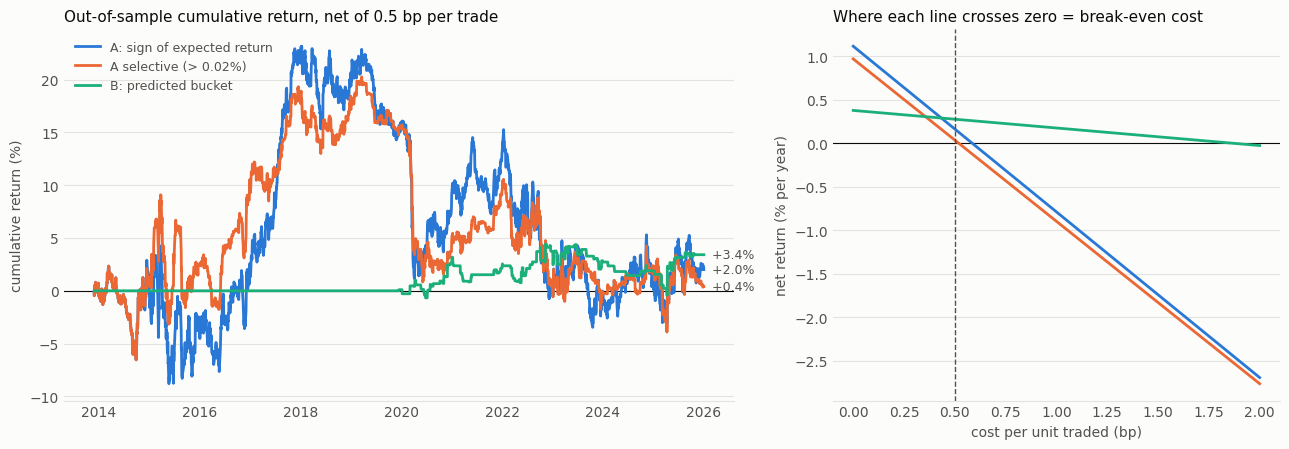

In [9]:
# ============================================================
# STEP 8 — Costs and performance metrics
# ============================================================
COST_BP   = 0.5        # cost per unit of position traded, in basis points (1 bp = 0.01%)
THRESHOLD = 0.02       # selective rule: trade only if |expected return| exceeds this (% per day)
DAYS_YEAR = 252


def position(bt, rule="ret", threshold=0.0):
    """Daily position (-1, 0, +1). rule 'ret': sign of expected return, only where it
    exceeds `threshold` in size; rule 'bucket': the predicted bucket."""
    in_tree = bt["depth"] > 0
    if rule == "bucket":
        return pd.Series(np.where(in_tree, bt["pred"], 0.0), index=bt.index)
    strong = in_tree & (bt["exp_ret"].abs() > threshold)
    return pd.Series(np.where(strong, np.sign(bt["exp_ret"]), 0.0), index=bt.index)


def net_returns(pos, ret, cost_bp=COST_BP):
    """Daily strategy return in %, after paying cost_bp on every unit of position change."""
    traded = pos.diff().abs()
    traded.iloc[0] = abs(pos.iloc[0])                   # opening the first position
    return pos * ret - traded * cost_bp / 100.0, traded


def metrics(pos, ret, cost_bp=COST_BP):
    """Performance summary of one position series at one cost level."""
    net, traded = net_returns(pos, ret, cost_bp)
    gross = pos * ret
    curve = net.cumsum()
    active = pos != 0
    return {
        "ann_return_%":   DAYS_YEAR * net.mean(),
        "ann_vol_%":      np.sqrt(DAYS_YEAR) * net.std(),
        "sharpe":         np.sqrt(DAYS_YEAR) * net.mean() / net.std() if net.std() > 0 else np.nan,
        "t_stat":         np.sqrt(len(net)) * net.mean() / net.std() if net.std() > 0 else np.nan,
        "max_drawdown_%": (curve - curve.cummax()).min(),
        "in_market_%":    100 * active.mean(),
        "hit_rate_%":     100 * (gross[active] > 0).mean() if active.any() else np.nan,
        "turnover_/yr":   DAYS_YEAR * traded.mean(),    # units of position traded per year
        "breakeven_bp":   100 * gross.sum() / traded.sum() if traded.sum() > 0 else np.nan,
    }


def plot_performance(strategies, ret, cost_bp=COST_BP, max_cost_bp=2.0):
    """Left: cumulative net return. Right: net annual return as the cost rises."""
    INK, MUTED, GRID, SURF = "#0b0b0b", "#52514e", "#e4e3df", "#fcfcfb"
    COL = ["#2a78d6", "#eb6834", "#1baf7a"]
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.6), facecolor=SURF,
                                   gridspec_kw={"width_ratios": [1.5, 1]})
    for ax in (ax1, ax2):
        ax.set_facecolor(SURF)
        ax.spines[["top", "right", "left"]].set_visible(False)
        ax.spines["bottom"].set_color(GRID)
        ax.tick_params(colors=MUTED, length=0)
        ax.grid(axis="y", color=GRID, lw=0.8)
        ax.axhline(0, color=INK, lw=0.8)

    costs = np.linspace(0, max_cost_bp, 21)
    for (name, pos), colour in zip(strategies.items(), COL):
        curve = net_returns(pos, ret, cost_bp)[0].cumsum()
        ax1.plot(curve.index, curve, color=colour, lw=2, label=name)
        ax1.text(curve.index[-1], curve.iloc[-1], f"  {curve.iloc[-1]:+.1f}%",
                 color=MUTED, fontsize=9, va="center")
        ax2.plot(costs, [DAYS_YEAR * net_returns(pos, ret, c)[0].mean() for c in costs],
                 color=colour, lw=2, label=name)
    ax1.set_ylabel("cumulative return (%)", color=MUTED)
    ax1.set_title(f"Out-of-sample cumulative return, net of {cost_bp} bp per trade",
                  loc="left", fontsize=11, color=INK)
    ax1.legend(frameon=False, fontsize=9, labelcolor=MUTED, loc="upper left")
    ax2.axvline(cost_bp, color=MUTED, lw=1, ls="--")
    ax2.set_xlabel("cost per unit traded (bp)", color=MUTED)
    ax2.set_ylabel("net return (% per year)", color=MUTED)
    ax2.set_title("Where each line crosses zero = break-even cost",
                  loc="left", fontsize=11, color=INK)
    plt.tight_layout()
    plt.show()


strategies = {
    "A: sign of expected return":      position(bt, "ret"),
    f"A selective (> {THRESHOLD}%)":   position(bt, "ret", THRESHOLD),
    "B: predicted bucket":             position(bt, "bucket"),
}

gross = pd.DataFrame({k: metrics(p, bt["ret"], 0.0) for k, p in strategies.items()}).T
net   = pd.DataFrame({k: metrics(p, bt["ret"], COST_BP) for k, p in strategies.items()}).T

print("BEFORE COSTS")
print(gross.round(2).to_string(), "\n")
print(f"AFTER COSTS ({COST_BP} bp per unit traded)")
print(net.round(2).to_string())
plot_performance(strategies, bt["ret"])